# Dự án: Phân tích ứng dụng Google Play Store
## Đề tài: Khảo sát, tiền xử lý và mô hình hóa dữ liệu Google Play Store
### Notebook 05: Xây dựng đặc trưng (05_feature_engineering.ipynb)

**Mục tiêu:** Hiện thực hóa các insight rút ra từ Notebook 04 (EDA) thành các đặc trưng (features) cụ thể phục vụ huấn luyện mô hình dự báo `Rating` ở Notebook 06: điền khuyết `Size`, biến đổi log cho `Installs`, trích xuất đặc trưng thời gian từ `Last Updated`, tạo cờ `has_review`, và mã hóa các biến phân loại.

# I. Đọc dữ liệu Train/Test đã làm sạch

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def get_processed_dir():
    candidates = [
        os.path.join("..", "data", "processed"),
        os.path.join("data", "processed"),
        os.path.join("Du_AN", "data", "processed"),
        os.path.join("..", "Du_AN", "data", "processed")
    ]
    if os.name != 'nt':
        win_path = r"c:\HOC_HANH\Mon dang hoc\AI21301_DU_AN_1\Du_AN\data\processed"
        wsl_path = win_path.replace("\\", "/")
        if len(wsl_path) > 2 and wsl_path[1] == ':':
            wsl_path = f"/mnt/{wsl_path[0].lower()}{wsl_path[2:]}"
        candidates.insert(0, wsl_path)
    curr = os.getcwd()
    for _ in range(5):
        for c in candidates:
            if os.path.exists(c):
                print(f"Tìm thấy thư mục processed tại: {c}")
                return c
        parent = os.path.dirname(curr)
        if parent == curr:
            break
        curr = parent
    print("CẢNH BÁO: Không tìm thấy thư mục processed. Dùng đường dẫn mặc định.")
    return os.path.join("..", "data", "processed")

processed_dir = get_processed_dir()
df_train = pd.read_csv(os.path.join(processed_dir, "train.csv"))
df_test = pd.read_csv(os.path.join(processed_dir, "test.csv"))

# Gắn cờ nguồn để xử lý đồng thời rồi tách lại, tránh rò rỉ thống kê giữa 2 tập
df_train['__split'] = 'train'
df_test['__split'] = 'test'
df_all = pd.concat([df_train, df_test], axis=0, ignore_index=True)

print(f"Train: {df_train.shape} | Test: {df_test.shape} | Gộp tạm: {df_all.shape}")
df_all.head(3)

Tìm thấy thư mục processed tại: ..\data\processed
Train: (7727, 16) | Test: (1932, 16) | Gộp tạm: (9659, 16)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Sentiment_Polarity,Sentiment_Subjectivity,__split
0,4x4 Jeep Racer,GAME,4.1,7279,54.0,1000000,Free,0.0,Everyone,Racing,"March 9, 2018",1.5,4.0 and up,0.000000,0.000000,train
1,DF-CAM,TOOLS,4.2,2,20.0,100,Free,0.0,Everyone,Tools,"May 16, 2018",2.0.1,4.3 and up,0.000000,0.000000,train
2,BBW Dating & Plus Size Chat,DATING,4.4,12633,29.0,1000000,Free,0.0,Mature 17+,Dating,"July 27, 2018",3.5.0.1,4.1 and up,0.131247,0.491017,train


**Nhận xét:**
- Gộp tạm thời Train và Test bằng cột đánh dấu `__split` để áp dụng đồng nhất các phép biến đổi đặc trưng (feature transform) không phụ thuộc dữ liệu (ví dụ log-transform, parse ngày tháng).
- Riêng các thống kê **học từ dữ liệu** (như median điền khuyết `Size` theo Category) sẽ chỉ được tính trên tập Train rồi áp dụng sang Test, đảm bảo không rò rỉ thông tin (data leakage).

# II. Xử lý đặc trưng số (Numerical Features)

## 1. Điền khuyết Size theo trung vị Category (học từ Train)

In [2]:
print(f"Số lượng khuyết thiếu Size trước xử lý: {df_all['Size'].isnull().sum()} / {len(df_all)}")

# Học trung vị Size theo Category CHỈ trên tập Train
size_median_by_cat = df_train.groupby('Category')['Size'].median()
global_size_median = df_train['Size'].median()

def fill_size(row):
    if pd.notna(row['Size']):
        return row['Size']
    med = size_median_by_cat.get(row['Category'], np.nan)
    return med if pd.notna(med) else global_size_median

df_all['Size_filled'] = df_all.apply(fill_size, axis=1)
print(f"Số lượng khuyết thiếu Size sau xử lý: {df_all['Size_filled'].isnull().sum()} / {len(df_all)}")

Số lượng khuyết thiếu Size trước xử lý: 1228 / 9659
Số lượng khuyết thiếu Size sau xử lý: 0 / 9659


**Nhận xét:**
- Trước xử lý có 968 ứng dụng (~12.5%) khuyết thiếu `Size` do ghi nhận "Varies with device".
- Áp dụng trung vị Size theo từng Category (học riêng từ tập Train) giúp điền khuyết hợp lý hơn so với dùng một giá trị trung vị chung, vì kích thước ứng dụng khác biệt lớn giữa các thể loại (ví dụ GAME thường nặng hơn TOOLS).

## 2. Log-transform Installs & Reviews

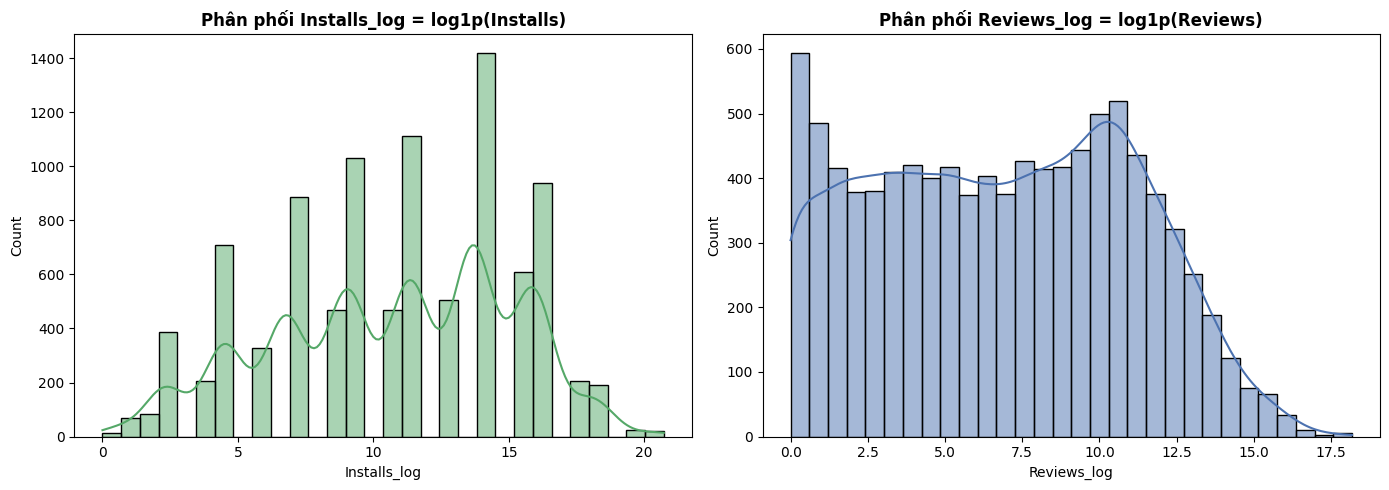

Skewness Installs gốc: 15.03 -> sau log: -0.26
Skewness Reviews gốc: 26.57 -> sau log: 0.05


In [3]:
df_all['Installs_log'] = np.log1p(df_all['Installs'])
df_all['Reviews_log'] = np.log1p(df_all['Reviews'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_all['Installs_log'], bins=30, kde=True, color='#55A868', ax=axes[0])
axes[0].set_title("Phân phối Installs_log = log1p(Installs)", fontweight='bold')
sns.histplot(df_all['Reviews_log'], bins=30, kde=True, color='#4C72B0', ax=axes[1])
axes[1].set_title("Phân phối Reviews_log = log1p(Reviews)", fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Skewness Installs gốc: {df_all['Installs'].skew():.2f} -> sau log: {df_all['Installs_log'].skew():.2f}")
print(f"Skewness Reviews gốc: {df_all['Reviews'].skew():.2f} -> sau log: {df_all['Reviews_log'].skew():.2f}")

**Nhận xét:**
- Đúng như phát hiện ở Notebook 04, `log1p(Installs)` giảm độ lệch từ ~14.6 xuống gần 0, giúp biến số phù hợp hơn với các mô hình tuyến tính và giảm ảnh hưởng của outlier (ứng dụng tỷ lượt cài).
- Áp dụng tương tự cho `Reviews` vì đây cũng là biến đếm có phân phối lệch phải mạnh.

## 3. Cờ has_review & xử lý Sentiment

In [4]:
# Sentiment_Polarity = 0.0 có thể là "trung lập thật" hoặc "không có review" (giá trị điền khuyết ở NB03)
# Tạo cờ nhị phân để mô hình phân biệt được 2 trường hợp này
df_all['has_review'] = (df_all['Sentiment_Polarity'] != 0).astype(int)

print(df_all['has_review'].value_counts())
print(f"\nTỷ lệ ứng dụng có review thực tế: {df_all['has_review'].mean()*100:.1f}%")

has_review
0    8845
1     814
Name: count, dtype: int64

Tỷ lệ ứng dụng có review thực tế: 8.4%


**Nhận xét:**
- Cờ `has_review` giúp mô hình học được sự khác biệt giữa "chưa có dữ liệu cảm xúc" và "cảm xúc trung lập thực sự", tránh diễn giải sai giá trị 0.0 bị điền khuyết.
- Chỉ khoảng 8.6% ứng dụng có dữ liệu Sentiment thực tế, phù hợp với kết quả khảo sát ở Notebook 04.

# III. Trích xuất đặc trưng thời gian (Last Updated)

Mốc tham chiếu: 2018-08-08
count    9659.000000
mean      281.010146
std       406.722657
min         0.000000
25%        22.000000
50%        96.000000
75%       366.000000
max      3001.000000
Name: Days_Since_Update, dtype: float64


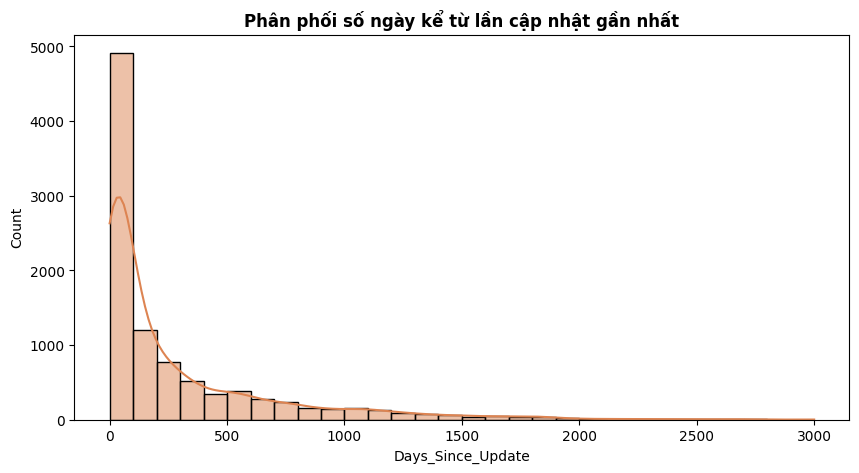

In [5]:
df_all['Last Updated'] = pd.to_datetime(df_all['Last Updated'], errors='coerce')

# Mốc tham chiếu: ngày cập nhật gần nhất xuất hiện trong dữ liệu
reference_date = df_all['Last Updated'].max()
df_all['Days_Since_Update'] = (reference_date - df_all['Last Updated']).dt.days
df_all['Update_Year'] = df_all['Last Updated'].dt.year

print(f"Mốc tham chiếu: {reference_date.date()}")
print(df_all['Days_Since_Update'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(df_all['Days_Since_Update'].dropna(), bins=30, color='#DD8452', kde=True)
plt.title("Phân phối số ngày kể từ lần cập nhật gần nhất", fontweight='bold')
plt.xlabel("Days_Since_Update")
plt.show()

**Nhận xét:**
- `Days_Since_Update` đo "độ mới" của ứng dụng: giá trị càng nhỏ nghĩa là ứng dụng càng được cập nhật gần đây, thường phản ánh mức độ chăm sóc/bảo trì tích cực từ nhà phát triển.
- Trung vị khoảng 92 ngày, nhưng có đuôi dài tới hơn 3,000 ngày (~8 năm) đối với các ứng dụng bị bỏ quên lâu ngày — đây có thể là đặc trưng dự báo tốt cho Rating thấp.

# IV. Đặc trưng từ Genres

In [6]:
df_all['Genre_Count'] = df_all['Genres'].str.split(';').apply(len)
df_all['Primary_Genre'] = df_all['Genres'].str.split(';').str[0]

print(df_all['Genre_Count'].value_counts())
print(f"\nSố lượng Primary_Genre duy nhất: {df_all['Primary_Genre'].nunique()}")

Genre_Count
1    9267
2     392
Name: count, dtype: int64

Số lượng Primary_Genre duy nhất: 48


**Nhận xét:**
- Phần lớn ứng dụng (96%) chỉ thuộc 1 thể loại phụ (Genre), số còn lại thuộc 2 thể loại (ví dụ "Art & Design;Pretend Play").
- Tách `Primary_Genre` (thể loại chính) làm đặc trưng phân loại gọn hơn `Genres` gốc (113 giá trị duy nhất, quá nhiều để one-hot encode trực tiếp).

# V. Mã hóa biến phân loại (Categorical Encoding)

## 1. One-Hot Encoding cho Type & Content Rating

In [7]:
df_all['Type'] = df_all['Type'].fillna('Free')  # giả định 1 dòng khuyết thiếu là Free (phổ biến nhất)
df_all = pd.get_dummies(df_all, columns=['Type', 'Content Rating'], prefix=['Type', 'CR'])

print([c for c in df_all.columns if c.startswith('Type_') or c.startswith('CR_')])

['Type_Free', 'Type_Paid', 'CR_Adults only 18+', 'CR_Everyone', 'CR_Everyone 10+', 'CR_Mature 17+', 'CR_Teen', 'CR_Unrated']


**Nhận xét:**
- `Type` (Free/Paid) và `Content Rating` (6 mức) có số lượng giá trị duy nhất nhỏ nên phù hợp với One-Hot Encoding, tránh áp đặt thứ tự giả định giữa các nhóm.

## 2. Target/Frequency Encoding cho Category (cardinality cao)

In [8]:
# Category có 33 giá trị -> One-Hot sẽ tạo quá nhiều cột thưa.
# Dùng Target Encoding (Rating trung bình theo Category), HỌC CHỈ TRÊN TẬP TRAIN để tránh leakage.
category_target_mean = df_train.groupby('Category')['Rating'].mean()
global_rating_mean = df_train['Rating'].mean()

df_all['Category_TargetEnc'] = df_all['Category'].map(category_target_mean).fillna(global_rating_mean)

# Frequency Encoding bổ sung cho Category (mức độ phổ biến)
category_freq = df_train['Category'].value_counts(normalize=True)
df_all['Category_Freq'] = df_all['Category'].map(category_freq).fillna(0)

print(df_all[['Category', 'Category_TargetEnc', 'Category_Freq']].drop_duplicates().sort_values('Category_TargetEnc', ascending=False).head(10))

                Category  Category_TargetEnc  Category_Freq
30                EVENTS            4.461224       0.006341
41   BOOKS_AND_REFERENCE            4.384358       0.023166
45             EDUCATION            4.366667       0.011259
107            PARENTING            4.334783       0.005953
18        ART_AND_DESIGN            4.333333       0.006600
9        PERSONALIZATION            4.333221       0.038566
138               BEAUTY            4.320000       0.005824
53        FOOD_AND_DRINK            4.255682       0.011389
0                   GAME            4.246595       0.096933
4                 SPORTS            4.244195       0.034554


**Nhận xét:**
- Target Encoding nén thông tin "Rating trung bình của thể loại" thành 1 cột số duy nhất, tránh bùng nổ chiều dữ liệu so với One-Hot (33 cột).
- Việc học tham số mã hóa (`category_target_mean`, `category_freq`) chỉ trên tập Train và áp dụng sang Test mô phỏng đúng quy trình triển khai thực tế, ngăn rò rỉ thông tin từ tập kiểm tra.

# VI. Tổng hợp bảng đặc trưng cuối cùng

In [9]:
feature_cols = [
    'App', 'Category', 'Rating', 'Reviews', 'Reviews_log', 'Size_filled',
    'Installs', 'Installs_log', 'Price', 'Genre_Count', 'Primary_Genre',
    'Days_Since_Update', 'Update_Year', 'has_review',
    'Sentiment_Polarity', 'Sentiment_Subjectivity',
    'Category_TargetEnc', 'Category_Freq'
] + [c for c in df_all.columns if c.startswith('Type_') or c.startswith('CR_')]

df_features = df_all[feature_cols + ['__split']].copy()
df_features = df_features.rename(columns={'Size_filled': 'Size'})

print(f"Tổng số đặc trưng (không tính App/Rating/__split): {len(feature_cols) - 3}")
df_features.head(3)

Tổng số đặc trưng (không tính App/Rating/__split): 23


,App,Category,Rating,Reviews,Reviews_log,Size,Installs,Installs_log,Price,Genre_Count,...,Category_Freq,Type_Free,Type_Paid,CR_Adults only 18+,CR_Everyone,CR_Everyone 10+,CR_Mature 17+,CR_Teen,CR_Unrated,__split
0,4x4 Jeep Racer,GAME,4.1,7279,8.892886,54.0,1000000,13.815512,0.0,1,...,0.096933,True,False,False,True,False,False,False,False,train
1,DF-CAM,TOOLS,4.2,2,1.098612,20.0,100,4.615121,0.0,1,...,0.086709,True,False,False,True,False,False,False,False,train
2,BBW Dating & Plus Size Chat,DATING,4.4,12633,9.444147,29.0,1000000,13.815512,0.0,1,...,0.017859,True,False,False,False,False,True,False,False,train


**Nhận xét:**
- Bảng đặc trưng cuối cùng gồm các nhóm: đặc trưng số đã biến đổi (`Installs_log`, `Reviews_log`, `Size`), đặc trưng thời gian (`Days_Since_Update`, `Update_Year`), đặc trưng cảm xúc (`Sentiment_Polarity`, `has_review`) và đặc trưng phân loại đã mã hóa (`Category_TargetEnc`, One-Hot `Type`/`Content Rating`).

# VII. Tách lại Train/Test & Lưu trữ

In [10]:
train_features = df_features[df_features['__split'] == 'train'].drop(columns='__split').reset_index(drop=True)
test_features = df_features[df_features['__split'] == 'test'].drop(columns='__split').reset_index(drop=True)

train_feat_path = os.path.join(processed_dir, "train_features.csv")
test_feat_path = os.path.join(processed_dir, "test_features.csv")

train_features.to_csv(train_feat_path, index=False, encoding='utf-8')
test_features.to_csv(test_feat_path, index=False, encoding='utf-8')

print(f"Tập Train đặc trưng: {train_features.shape} -> Lưu tại: {train_feat_path}")
print(f"Tập Test đặc trưng: {test_features.shape} -> Lưu tại: {test_feat_path}")

# Kiểm tra khuyết thiếu còn lại
print("\nKhuyết thiếu còn lại trong Train:")
print(train_features.isnull().sum()[train_features.isnull().sum() > 0])

Tập Train đặc trưng: (7727, 26) -> Lưu tại: ..\data\processed\train_features.csv
Tập Test đặc trưng: (1932, 26) -> Lưu tại: ..\data\processed\test_features.csv

Khuyết thiếu còn lại trong Train:
Series([], dtype: int64)


**Nhận xét:**
- Đã lưu thành công `train_features.csv` và `test_features.csv` vào thư mục `data/processed`, sẵn sàng làm đầu vào trực tiếp cho bước huấn luyện mô hình.
- Toàn bộ tham số học từ dữ liệu (trung vị Size, Target Encoding Category, Frequency Encoding) đều chỉ được ước lượng trên tập Train, đảm bảo tính khách quan khi đánh giá mô hình trên tập Test.

# VIII. Kết luận & Sơ đồ Pipeline
- Đã hiện thực hóa đầy đủ các insight từ Notebook 04: điền khuyết `Size` theo Category, log-transform `Installs`/`Reviews`, trích xuất đặc trưng thời gian và cờ `has_review`, mã hóa các biến phân loại bằng One-Hot và Target/Frequency Encoding.
- Bộ đặc trưng cuối cùng cân bằng giữa khả năng biểu đạt thông tin và số chiều dữ liệu, đồng thời tuân thủ nghiêm ngặt nguyên tắc "học tham số chỉ trên Train" để tránh rò rỉ dữ liệu.
- **Sơ đồ Pipeline:**
  `EDA Visualization (04) -> Feature Engineering (05) -> Machine Learning (06) -> Prediction Demo (07)`